In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import pandas as pd
from IPython.display import display
import scipy.integrate as spi

In [9]:
# Определяем переменные
x = sp.Symbol('x', real=True)
a, b = 0.514, -0.461

# Оригинальная функция
f = lambda x: np.exp(a * x**3 + b * x)

# Выражения Тейлора
T2 = 1 + b*x + (b**2/2)*x**2
T4 = 1 + b*x + (b**2/2)*x**2 + ((b**3 + 6*a)/6)*x**3 + ((b**4 + 24*a*b)/24)*x**4

# Функции для вычисления численных значений
T2 = sp.lambdify(x, T2, 'numpy')
T4 = sp.lambdify(x, T4, 'numpy')

# Функция интерполяционного многочлена P2(x)
def P2(x):
    term1 = np.exp(-a - b) * (x * (x - 1)) / 2
    term2 = (1 - x**2)
    term3 = np.exp(a + b) * (x * (x + 1)) / 2
    return term1 + term2 + term3

# Функция интерполяционного многочлена P4(x)
def P4(x):
    term1 = (2/3) * x * (x - 1) * (x - 0.5) * (x + 0.5) * np.exp(-a - b)
    term2 = (-8/3) * x * (x - 1) * (x - 0.5) * (x + 1) * np.exp(-a/8 - b/2)
    term3 = (-8/3) * x * (x - 1) * (x + 0.5) * (x + 1) * np.exp(a/8 + b/2)
    term4 = (2/3) * x * (x - 0.5) * (x + 0.5) * (x + 1) * np.exp(a + b)
    term5 = 4 * (x - 1) * (x - 0.5) * (x + 0.5) * (x + 1)
    return term1 + term2 + term3 + term4 + term5

# Инициализируем значения аргумента, вычисляем значения функции и её приближений
x_vals = np.arange(-1, 1.01, 0.01)
f_vals = f(x_vals)

T2_vals = T2(x_vals)
T4_vals = T4(x_vals)

P2_vals = P2(x_vals)
P4_vals = P4(x_vals)

err_T2 = np.abs(f_vals - T2_vals)
err_T4 = np.abs(f_vals - T4_vals)

err_P2 = np.abs(f_vals - P2_vals)
err_P4 = np.abs(f_vals - P4_vals)

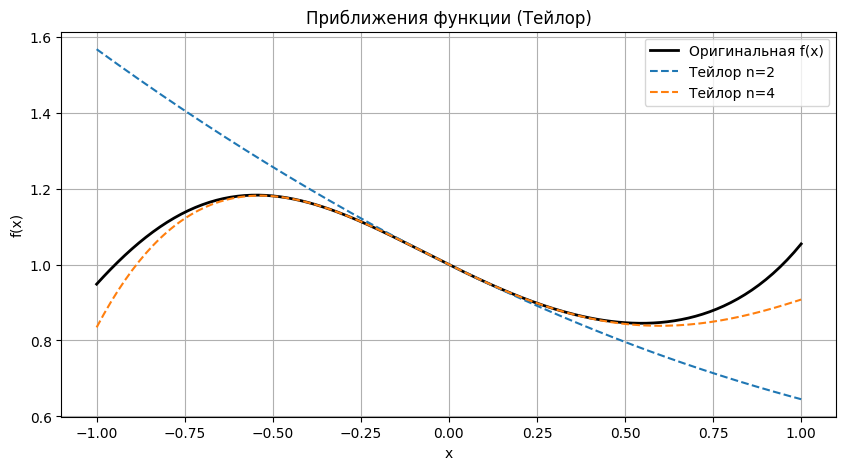

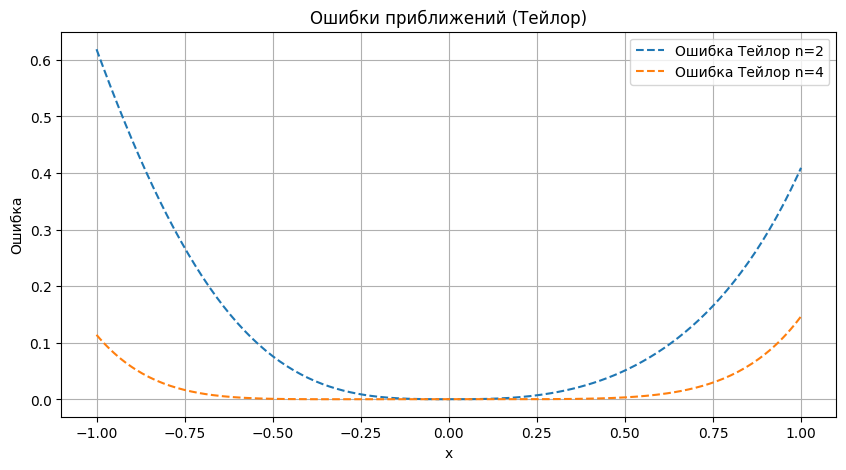

,x,f(x),T2(x),T4(x),Err T2,Err T4
0,-1.00,0.948380,1.567261,0.834517,0.618880,0.113863
1,-0.99,0.958540,1.560536,0.851837,0.601996,0.106704
2,-0.98,0.968514,1.553833,0.868605,0.585319,0.099908
3,-0.97,0.978295,1.547151,0.884832,0.568855,0.093463
4,-0.96,0.987880,1.540490,0.900524,0.552610,0.087355
...,...,...,...,...,...,...
196,0.96,1.012269,0.655370,0.896020,0.356899,0.116249
197,0.97,1.022186,0.652811,0.898914,0.369376,0.123272
198,0.98,1.032510,0.650273,0.901854,0.382237,0.130656
199,0.99,1.043253,0.647756,0.904837,0.395497,0.138416


In [10]:
# График приближений Тейлора
plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_vals, label="Оригинальная f(x)", linewidth=2, color='black')
plt.plot(x_vals, T2_vals, label="Тейлор n=2", linestyle='dashed')
plt.plot(x_vals, T4_vals, label="Тейлор n=4", linestyle='dashed')
plt.legend()
plt.title("Приближения функции (Тейлор)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()
#График отклонений
plt.figure(figsize=(10, 5))
plt.plot(x_vals, err_T2, label="Ошибка Тейлор n=2", linestyle='dashed')
plt.plot(x_vals, err_T4, label="Ошибка Тейлор n=4", linestyle='dashed')
plt.legend()
plt.title("Ошибки приближений (Тейлор)")
plt.xlabel("x")
plt.ylabel("Ошибка")
plt.grid()
plt.show()

df_taylor = pd.DataFrame({
    "x": x_vals,
    "f(x)": f_vals,
    "T2(x)": T2_vals,
    "T4(x)": T4_vals,
    "Err T2": err_T2,
    "Err T4": err_T4
})

display(df_taylor)

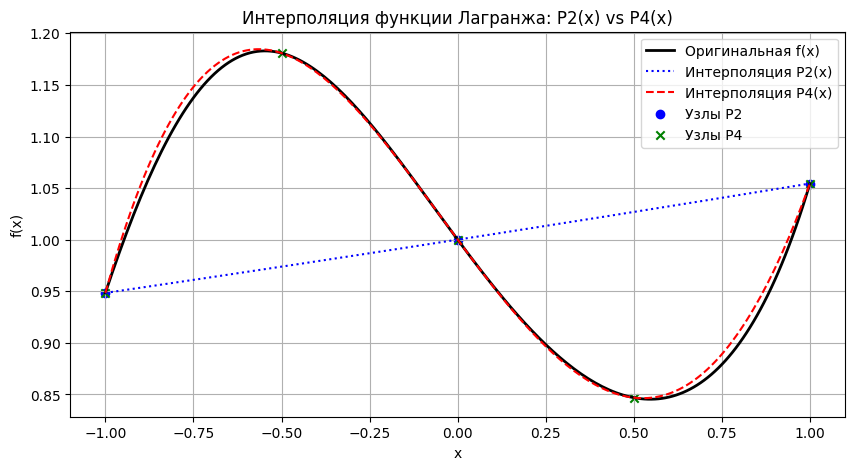

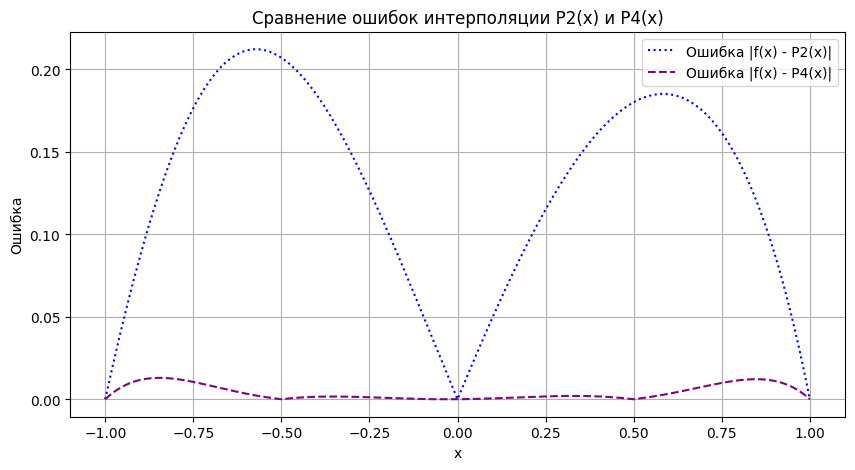

,x,f(x),P2(x),P4(x),Err P2,Err P4
0,-1.00,0.948380,0.948380,0.948380,0.000000e+00,0.000000e+00
1,-0.99,0.958540,0.948882,0.960454,9.657983e-03,1.913579e-03
2,-0.98,0.968514,0.949385,0.972151,1.912879e-02,3.637504e-03
3,-0.97,0.978295,0.949888,0.983477,2.840736e-02,5.181620e-03
4,-0.96,0.987880,0.950391,0.994435,3.748888e-02,6.555544e-03
...,...,...,...,...,...,...
196,0.96,1.012269,1.052199,1.018559,3.992956e-02,6.289770e-03
197,0.97,1.022186,1.052756,1.027174,3.056941e-02,4.987976e-03
198,0.98,1.032510,1.053314,1.036024,2.080356e-02,3.513932e-03
199,0.99,1.043253,1.053871,1.045108,1.061847e-02,1.855523e-03


In [11]:
# График f(x), P2(x) и P4(x)
plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_vals, label="Оригинальная f(x)", linewidth=2, color='black')
plt.plot(x_vals, P2_vals, label="Интерполяция P2(x)", linestyle='dotted', color='blue')
plt.plot(x_vals, P4_vals, label="Интерполяция P4(x)", linestyle='dashed', color='red')
plt.scatter([-1, 0, 1], f(np.array([-1, 0, 1])), color='blue', marker='o', label="Узлы P2")
plt.scatter([-1, -0.5, 0, 0.5, 1], f(np.array([-1, -0.5, 0, 0.5, 1])), color='green', marker='x', label="Узлы P4")
plt.legend()
plt.title("Интерполяция функции Лагранжа: P2(x) vs P4(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()
#График отклонений
plt.figure(figsize=(10, 5))
plt.plot(x_vals, err_P2, label="Ошибка |f(x) - P2(x)|", linestyle='dotted', color='blue')
plt.plot(x_vals, err_P4, label="Ошибка |f(x) - P4(x)|", linestyle='dashed', color='purple')
plt.legend()
plt.title("Сравнение ошибок интерполяции P2(x) и P4(x)")
plt.xlabel("x")
plt.ylabel("Ошибка")
plt.grid()
plt.show()

df_lagrange = pd.DataFrame({
    "x": x_vals,
    "f(x)": f_vals,
    "P2(x)": P2_vals,
    "P4(x)": P4_vals,
    "Err P2": err_P2,
    "Err P4": err_P4
})

display(df_lagrange)

In [12]:
# Заданные параметры
a, b = 0.514, -0.461  # коэффициенты
A, B = -1, 1          # границы интерполяции
N = 100               # количество разбиений для метода трапеций
L = (B-A)/2
# Метод трапеций для вычисления интегралов
def trapezoidal_rule(func, N):
    x_vals = np.linspace(A, B, N + 1)
    h = (B - A) / N
    integral = 0.5 * (func(x_vals[0]) + func(x_vals[-1])) + np.sum(func(x_vals[1:-1]))
    return h * integral

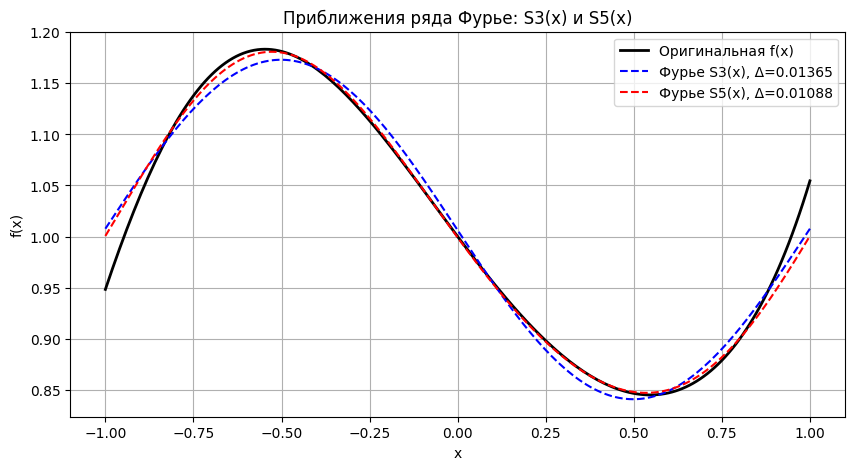

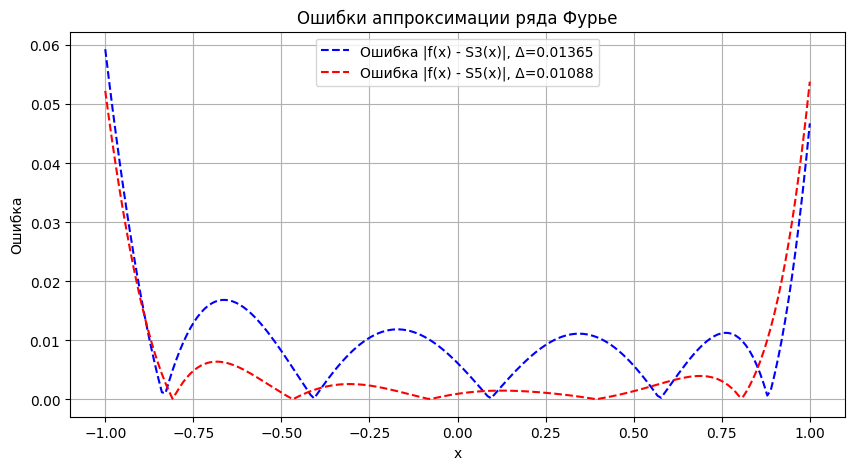

Мера отклонения Δ для S3(x): 0.01365
Мера отклонения Δ для S5(x): 0.01088


,x,f(x),S3(x),S5(x),|f(x) - S3(x)|,|f(x) - S5(x)|
0,-1.000000e+00,0.948380,1.007687,1.000624,0.059307,0.052244
1,-9.000000e-01,1.041013,1.058878,1.057921,0.017865,0.016908
2,-8.000000e-01,1.111413,1.104982,1.110496,0.006430,0.000917
3,-7.000000e-01,1.157657,1.141488,1.151366,0.016169,0.006291
4,-6.000000e-01,1.180073,1.164820,1.175290,0.015253,0.004783
5,-5.000000e-01,1.180868,1.172695,1.179757,0.008173,0.001111
6,-4.000000e-01,1.163583,1.164343,1.165300,0.000760,0.001717
7,-3.000000e-01,1.132494,1.140580,1.135066,0.008086,0.002573
8,-2.000000e-01,1.092084,1.103733,1.093855,0.011649,0.001771
9,-1.000000e-01,1.046641,1.057409,1.046939,0.010768,0.000298


In [13]:
# Вычисляем коэффициенты Фурье методом трапеций
a0 = trapezoidal_rule(lambda x: f(x), N)
a1 = trapezoidal_rule(lambda x: f(x) * np.cos(np.pi * x), N)
b1 = trapezoidal_rule(lambda x: f(x) * np.sin(np.pi * x), N)
a2 = trapezoidal_rule(lambda x: f(x) * np.cos(2 * np.pi * x), N)
b2 = trapezoidal_rule(lambda x: f(x) * np.sin(2 * np.pi * x), N)

# Функции для S3(x) и S5(x)
def S3(x):
    return (a0 / 2) + a1 * np.cos(np.pi * x) + b1 * np.sin(np.pi * x)
def S5(x):
    return S3(x) + a2 * np.cos(2 * np.pi * x) + b2 * np.sin(2 * np.pi * x)

# Генерируем значения x для построения графиков
x_vals = np.linspace(A, B, 200)
f_vals = f(x_vals)
S3_vals = S3(x_vals)
S5_vals = S5(x_vals)

# Вычисляем меру отклонения Δ для S3 и S5
def compute_error(S_vals):
    error_integral = trapezoidal_rule(lambda x: (f(x) - S_vals[np.searchsorted(x_vals, x)])**2, 100)
    return np.sqrt(error_integral / (B - A))

Delta_S3 = compute_error(S3_vals)
Delta_S5 = compute_error(S5_vals)

# График приближений ряда Фурье
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(x_vals, f_vals, label="Оригинальная f(x)", linewidth=2, color="black")
ax1.plot(x_vals, S3_vals, label=f"Фурье S3(x), Δ={Delta_S3:.5f}", linestyle="dashed", color="blue")
ax1.plot(x_vals, S5_vals, label=f"Фурье S5(x), Δ={Delta_S5:.5f}", linestyle="dashed", color="red")
ax1.legend()
ax1.set_title("Приближения ряда Фурье: S3(x) и S5(x)")
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.grid()
plt.show()

# График ошибки аппроксимации
err_S3 = np.abs(f_vals - S3_vals)
err_S5 = np.abs(f_vals - S5_vals)

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(x_vals, err_S3, label=f"Ошибка |f(x) - S3(x)|, Δ={Delta_S3:.5f}", linestyle="dashed", color="blue")
ax2.plot(x_vals, err_S5, label=f"Ошибка |f(x) - S5(x)|, Δ={Delta_S5:.5f}", linestyle="dashed", color="red")
ax2.legend()
ax2.set_title("Ошибки аппроксимации ряда Фурье")
ax2.set_xlabel("x")
ax2.set_ylabel("Ошибка")
ax2.grid()
plt.show()

# Таблица значений
x_table = np.arange(A, B + 0.1, 0.1)
df_table = pd.DataFrame({
    "x": x_table,
    "f(x)": f(x_table),
    "S3(x)": S3(x_table),
    "S5(x)": S5(x_table),
    "|f(x) - S3(x)|": np.abs(f(x_table) - S3(x_table)),
    "|f(x) - S5(x)|": np.abs(f(x_table) - S5(x_table))
})

# Отображение таблицы
print(f"Мера отклонения Δ для S3(x): {Delta_S3:.5f}")
print(f"Мера отклонения Δ для S5(x): {Delta_S5:.5f}")
display(df_table)

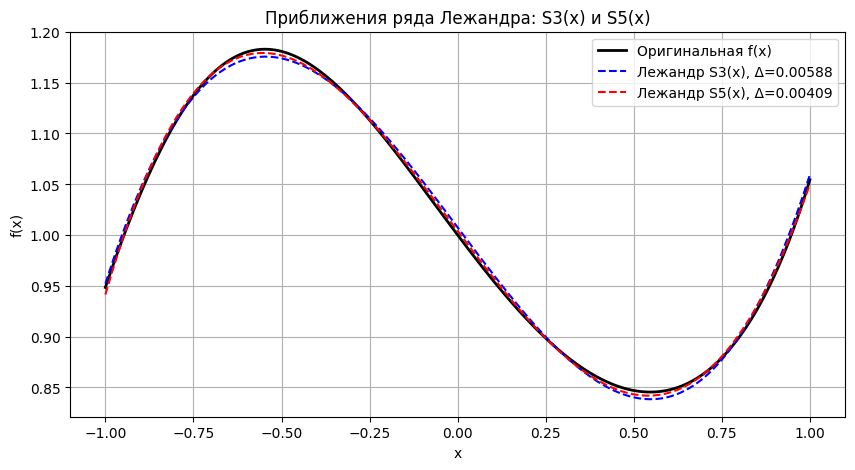

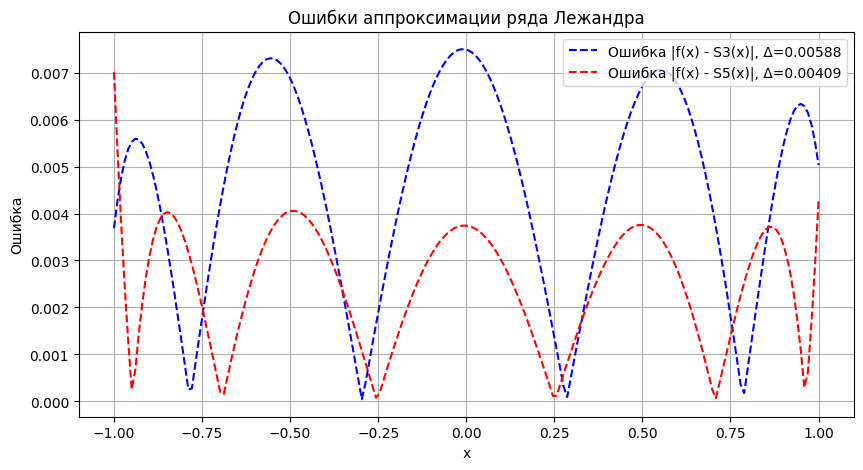

Мера отклонения Δ для S3(x): 0.00588
Мера отклонения Δ для S5(x): 0.00409


,x,f(x),S3(x),S5(x),|f(x) - S3(x)|,|f(x) - S5(x)|
0,-1.000000e+00,0.948380,0.952068,0.941370,0.003688,0.007010
1,-9.000000e-01,1.041013,1.046129,1.044080,0.005117,0.003067
2,-8.000000e-01,1.111413,1.112252,1.114861,0.000839,0.003448
3,-7.000000e-01,1.157657,1.153536,1.157911,0.004121,0.000254
4,-6.000000e-01,1.180073,1.173082,1.177267,0.006991,0.002805
5,-5.000000e-01,1.180868,1.173991,1.176817,0.006878,0.004051
6,-4.000000e-01,1.163583,1.159363,1.160302,0.004220,0.003281
7,-3.000000e-01,1.132494,1.132298,1.131326,0.000196,0.001167
8,-2.000000e-01,1.092084,1.095897,1.093362,0.003813,0.001278
9,-1.000000e-01,1.046641,1.053261,1.049758,0.006620,0.003117


In [14]:
# Полиномы Лежандра
P0 = lambda x: 1
P1 = lambda x: x
P2 = lambda x: 0.5 * (3*x**2 - 1)
P3 = lambda x: 0.5 * (5*x**3 - 3*x)
P4 = lambda x: 0.125 * (35*x**4 - 30*x**2 + 3)
P5 = lambda x: 0.125 * (63*x**5 - 70*x**3 + 15*x)

polynomials = [P0, P1, P2, P3, P4, P5]

# Вычисляем коэффициенты c_n вручную (метод трапеций)
def compute_legendre_coefficients(N):
    coeffs = []
    for n in range(N + 1):
        integral = trapezoidal_rule(lambda x: f(x) * polynomials[n](x), 100)
        cn = (2 * n + 1) / 2 * integral
        coeffs.append(cn)
    return np.array(coeffs)

# Приближённая сумма ряда Лежандра
def legendre_series(x, coeffs):
    S_N = np.zeros_like(x)
    for n, cn in enumerate(coeffs):
        S_N += cn * polynomials[n](x)
    return S_N

# Вычисляем коэффициенты вручную для N=3 и N=5
coeffs_3 = compute_legendre_coefficients(3)
coeffs_5 = compute_legendre_coefficients(5)

# Генерируем значения x для построения графиков
x_vals = np.linspace(A, B, 200)
f_vals = f(x_vals)
S3_vals = legendre_series(x_vals, coeffs_3)
S5_vals = legendre_series(x_vals, coeffs_5)

Delta_S3 = compute_error(S3_vals)
Delta_S5 = compute_error(S5_vals)

# График приближений ряда Лежандра
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, f_vals, label="Оригинальная f(x)", linewidth=2, color="black")
ax.plot(x_vals, S3_vals, label=f"Лежандр S3(x), Δ={Delta_S3:.5f}", linestyle="dashed", color="blue")
ax.plot(x_vals, S5_vals, label=f"Лежандр S5(x), Δ={Delta_S5:.5f}", linestyle="dashed", color="red")
ax.legend()
ax.set_title("Приближения ряда Лежандра: S3(x) и S5(x)")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid()
plt.show()

# График ошибок
err_S3 = np.abs(f_vals - S3_vals)
err_S5 = np.abs(f_vals - S5_vals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, err_S3, label=f"Ошибка |f(x) - S3(x)|, Δ={Delta_S3:.5f}", linestyle="dashed", color="blue")
ax.plot(x_vals, err_S5, label=f"Ошибка |f(x) - S5(x)|, Δ={Delta_S5:.5f}", linestyle="dashed", color="red")
ax.legend()
ax.set_title("Ошибки аппроксимации ряда Лежандра")
ax.set_xlabel("x")
ax.set_ylabel("Ошибка")
ax.grid()
plt.show()

# Таблица значений
x_table = np.arange(A, B + 0.1, 0.1)
df_table = pd.DataFrame({
    "x": x_table,
    "f(x)": f(x_table),
    "S3(x)": legendre_series(x_table, coeffs_3),
    "S5(x)": legendre_series(x_table, coeffs_5),
    "|f(x) - S3(x)|": np.abs(f(x_table) - legendre_series(x_table, coeffs_3)),
    "|f(x) - S5(x)|": np.abs(f(x_table) - legendre_series(x_table, coeffs_5))
})

# Отображение таблицы
print(f"Мера отклонения Δ для S3(x): {Delta_S3:.5f}")
print(f"Мера отклонения Δ для S5(x): {Delta_S5:.5f}")
display(df_table)
